In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
data = {
    "StudyHours": [2,3,4,5,6,7,8,9,1,4,6,7,3,5,8],
    "Attendance": [60,65,70,75,80,85,90,92,55,78,82,88,68,72,95],
    "PreviousMarks": [45,50,55,60,65,70,75,80,40,58,68,72,48,62,85],
    "AssignmentScore": [50,55,60,65,70,75,80,85,45,68,72,78,58,67,90],
    "FinalMarks": [48,53,59,65,71,77,83,88,43,63,73,79,52,66,91]
}

df = pd.DataFrame(data)

df

,StudyHours,Attendance,PreviousMarks,AssignmentScore,FinalMarks
0,2,60,45,50,48
1,3,65,50,55,53
2,4,70,55,60,59
3,5,75,60,65,65
4,6,80,65,70,71
5,7,85,70,75,77
6,8,90,75,80,83
7,9,92,80,85,88
8,1,55,40,45,43
9,4,78,58,68,63


In [4]:

# Select the input features
X = df[
    [
        "StudyHours",
        "Attendance",
        "PreviousMarks",
        "AssignmentScore"
    ]
]

# Select what we want to predict
y = df["FinalMarks"]

print("Input features (X):")
display(X.head())

print("Target values (y):")
display(y.head())

Input features (X):


,StudyHours,Attendance,PreviousMarks,AssignmentScore
0,2,60,45,50
1,3,65,50,55
2,4,70,55,60
3,5,75,60,65
4,6,80,65,70


Target values (y):


,FinalMarks
0,48
1,53
2,59
3,65
4,71


In [5]:

# Split the dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Machine Learning model trained successfully!")
print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Machine Learning model trained successfully!
Training records: 12
Testing records: 3


In [6]:

# Predict marks for the test records
predictions = model.predict(X_test)

# Calculate prediction error
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Actual marks:", list(y_test))
print("Predicted marks:", predictions.round(2).tolist())
print("Mean Absolute Error:", round(mae, 2))
print("R2 Score:", round(r2, 2))

Actual marks: [63, 79, 48]
Predicted marks: [62.39, 78.61, 47.78]
Mean Absolute Error: 0.41
R2 Score: 1.0


In [7]:

# Get details of a new student
study_hours = float(input("Study hours per day: "))
attendance = float(input("Attendance percentage (0-100): "))
previous_marks = float(input("Previous exam marks (0-100): "))
assignment_score = float(input("Assignment score (0-100): "))

# Prepare student information for the model
new_student = pd.DataFrame({
    "StudyHours": [study_hours],
    "Attendance": [attendance],
    "PreviousMarks": [previous_marks],
    "AssignmentScore": [assignment_score]
})

# Predict final marks
predicted_marks = model.predict(new_student)[0]

print("\n------------------------------")
print(" STUDENT PERFORMANCE RESULT")
print("------------------------------")
print("Predicted final marks:", round(predicted_marks, 2))
print("------------------------------")
print("Note: This is an experimental estimate.")

Study hours per day: 6
Attendance percentage (0-100): 75
Previous exam marks (0-100): 89
Assignment score (0-100): 67

------------------------------
 STUDENT PERFORMANCE RESULT
------------------------------
Predicted final marks: 90.39
------------------------------
Note: This is an experimental estimate.


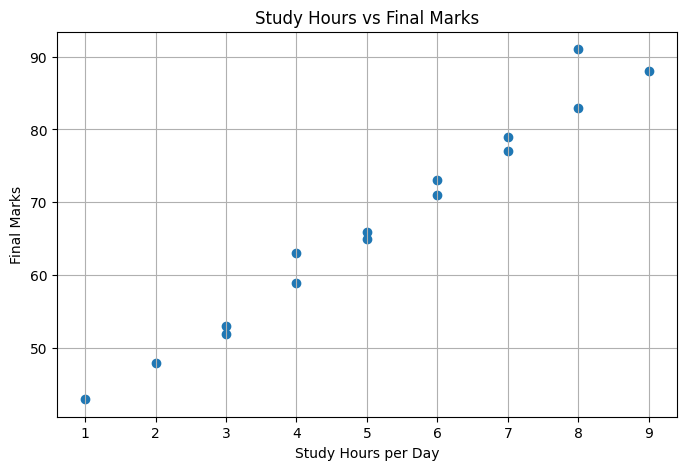

In [8]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df["StudyHours"],
    df["FinalMarks"]
)

plt.xlabel("Study Hours per Day")
plt.ylabel("Final Marks")
plt.title("Study Hours vs Final Marks")
plt.grid(True)

plt.show()

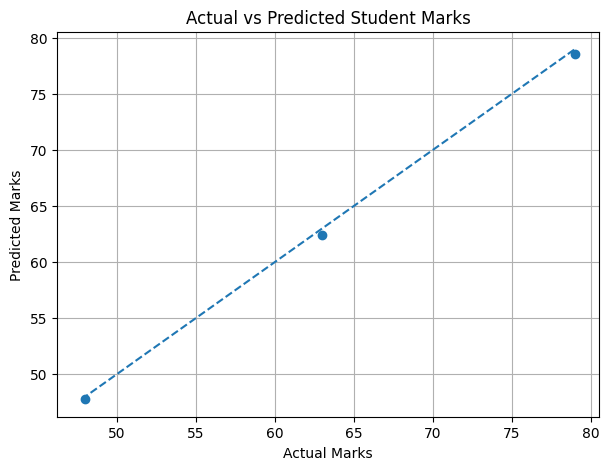

In [9]:

plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    predictions
)

# Reference line for perfect predictions
minimum = min(y_test.min(), predictions.min())
maximum = max(y_test.max(), predictions.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Student Marks")
plt.grid(True)

plt.show()

In [10]:

%pip -q install gradio

In [11]:

import gradio as gr
import pandas as pd

def predict_student(study_hours, attendance,
                    previous_marks, assignment_score):

    # Check that all values were entered
    values = [
        study_hours, attendance,
        previous_marks, assignment_score
    ]

    if any(v is None for v in values):
        return "Please enter all four values."

    if not (0 <= study_hours <= 24):
        return "Study hours must be between 0 and 24."

    if not (0 <= attendance <= 100):
        return "Attendance must be between 0 and 100."

    if not (0 <= previous_marks <= 100):
        return "Previous marks must be between 0 and 100."

    if not (0 <= assignment_score <= 100):
        return "Assignment score must be between 0 and 100."

    student = pd.DataFrame({
        "StudyHours": [study_hours],
        "Attendance": [attendance],
        "PreviousMarks": [previous_marks],
        "AssignmentScore": [assignment_score]
    })

    result = model.predict(student)[0]

    # Keep the displayed estimate within the marks range
    result = max(0, min(100, result))

    return (
        f"Predicted Final Marks: {result:.2f} / 100\n\n"
        "This is an experimental estimate, not a guarantee."
    )


with gr.Blocks() as demo:
    gr.Markdown("# Student Performance Prediction")
    gr.Markdown(
        "Enter student details to estimate final exam marks."
    )

    hours = gr.Number(
        label="Study Hours Per Day", value=6
    )
    attendance = gr.Number(
        label="Attendance (%)", value=85
    )
    previous = gr.Number(
        label="Previous Exam Marks", value=70
    )
    assignment = gr.Number(
        label="Assignment Score", value=75
    )

    predict_button = gr.Button("Predict Marks")
    output = gr.Textbox(label="Prediction Result")

    predict_button.click(
        fn=predict_student,
        inputs=[hours, attendance, previous, assignment],
        outputs=output
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://758491b09ad22870bb.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
